In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [3]:
from src.imports import *

# df = pd.read_pickle('../output/ontario_test.pkl')
df = pd.read_parquet(
    "../output/ontario",
    # columns=["file_index", "Eg", "Ev", "lat", "lon"],
)

# import duckdb

# con = duckdb.connect()

# result = con.execute("""
#     SELECT
#         file_index,
#         COUNT(*) AS n_rows
#     FROM read_parquet('../output/ontario_test_parquet/*.parquet')
#     GROUP BY file_index
#     ORDER BY file_index
# """).df()

In [4]:
mem_bytes = df.memory_usage(deep=True).sum()

print(f"{mem_bytes / 1024**2:.2f} MB")
print(f"{mem_bytes / 1024**3:.2f} GB")

4888.94 MB
4.77 GB


In [5]:
df

,folder,date,lon,lat,pvpg,pv,pg,Eg,Ev,data_quantity,...,h_te_best_fit,h_te_std,terrain_slope,longitude,latitude,cloud_flag_atm,layer_flag,file_index,ATL03,ATL08
0,ontario,24/10/2018,-93.243577,48.182688,0.659916,1.704473,2.582864,0.823529,0.647059,114,...,371.822571,0.186829,-0.001807,-93.242195,48.173679,0.0,0.0,5,../../scratch/ontario/ATL03_20181024210256_040...,../../scratch/ontario/ATL08_20181024210256_040...
1,ontario,24/10/2018,-93.243577,48.182688,0.659916,1.704473,2.582864,1.300000,0.650000,114,...,371.769078,0.308399,-0.004035,-93.242215,48.173807,0.0,0.0,5,../../scratch/ontario/ATL03_20181024210256_040...,../../scratch/ontario/ATL08_20181024210256_040...
2,ontario,24/10/2018,-93.243577,48.182688,0.659916,1.704473,2.582864,0.684211,1.000000,114,...,371.715585,0.259232,0.005539,-93.242234,48.173935,0.0,0.0,5,../../scratch/ontario/ATL03_20181024210256_040...,../../scratch/ontario/ATL08_20181024210256_040...
3,ontario,24/10/2018,-93.243577,48.182688,0.659916,1.704473,2.582864,0.647059,1.176471,114,...,371.662092,0.142362,0.001273,-93.242254,48.174064,0.0,0.0,5,../../scratch/ontario/ATL03_20181024210256_040...,../../scratch/ontario/ATL08_20181024210256_040...
4,ontario,24/10/2018,-93.243577,48.182688,0.659916,1.704473,2.582864,0.933333,0.600000,114,...,371.608599,0.227209,-0.003415,-93.242274,48.174192,0.0,0.0,5,../../scratch/ontario/ATL03_20181024210256_040...,../../scratch/ontario/ATL08_20181024210256_040...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11538564,ontario,16/12/2025,-89.038019,51.107577,0.698928,1.090875,1.560783,1.058824,0.352941,7,...,312.550156,0.199384,-0.005008,-89.037940,51.110757,0.0,0.0,1486,../../scratch/ontario/ATL03_20251216160453_003...,../../scratch/ontario/ATL08_20251216160453_003...
11538565,ontario,16/12/2025,-89.038019,51.107577,0.698928,1.090875,1.560783,1.214286,0.214286,7,...,312.549622,0.246216,-0.008298,-89.038048,51.111504,1.0,0.0,1486,../../scratch/ontario/ATL03_20251216160453_003...,../../scratch/ontario/ATL08_20251216160453_003...
11538566,ontario,16/12/2025,-89.038019,51.107577,0.698928,1.090875,1.560783,1.117647,0.294118,7,...,312.485611,0.177099,0.016882,-89.038069,51.111654,1.0,0.0,1486,../../scratch/ontario/ATL03_20251216160453_003...,../../scratch/ontario/ATL08_20251216160453_003...
11538567,ontario,16/12/2025,-89.038019,51.107577,0.698928,1.090875,1.560783,1.437500,0.125000,7,...,312.293579,0.170825,-0.014852,-89.038134,51.112104,1.0,0.0,1486,../../scratch/ontario/ATL03_20251216160453_003...,../../scratch/ontario/ATL08_20251216160453_003...


In [20]:
df.columns

Index(['folder', 'date', 'lon', 'lat', 'pvpg', 'pv', 'pg', 'Eg', 'Ev',
       'data_quantity', 'altitude', 'pv_ratio_mean', 'pv_ratio_max', 'beam',
       'beam_str', 'outlier', 'msw_flag', 'night_flag', 'asr',
       'canopy_openness', 'snr', 'segment_cover', 'segment_landcover',
       'h_te_best_fit', 'h_te_std', 'terrain_slope', 'longitude', 'latitude',
       'cloud_flag_atm', 'layer_flag', 'file_index', 'ATL03', 'ATL08'],
      dtype='object')

In [5]:
df['Eg_strong'] = np.where((df['beam_str'] == 'strong')&(df['outlier'] == 1), df['Eg'], np.nan)
df['Ev_strong'] = np.where((df['beam_str'] == 'strong')&(df['outlier'] == 1), df['Ev'], np.nan)
df['Eg_weak'] = np.where((df['beam_str'] == 'weak')&(df['outlier'] == 1), df['Eg'], np.nan)
df['Ev_weak'] = np.where((df['beam_str'] == 'weak')&(df['outlier'] == 1), df['Ev'], np.nan)
df['forest_type'] = np.where(df['segment_landcover']<119, 'closed', 'open')

import warnings

warnings.filterwarnings(
    "ignore",
    message="Mean of empty slice",
    category=RuntimeWarning,
    module="numpy.lib.nanfunctions",
)

df_grouped = df.groupby(['folder','date','lat','lon']).agg({
    'pvpg': 'mean',
    'pv': 'max',
    'pg': 'max',
    'Eg_strong': 'mean',
    'Ev_strong': 'mean',
    'Eg_weak': 'median',
    'Ev_weak': 'median',
    'data_quantity': 'max',
    'snr': 'mean',
    'layer_flag': 'mean',
    'file_index': 'mean',
    'msw_flag': 'mean',
    'pv_ratio_mean': 'mean',
    'pv_ratio_max': 'mean',
    'forest_type': lambda x: pd.Series.mode(x).iloc[0],
}).reset_index()

df_grouped = df_grouped.dropna(subset=['Eg_strong', 'Ev_strong'])

In [21]:
df_grouped

,folder,date,lat,lon,pvpg,pv,pg,Eg_strong,Ev_strong,Eg_weak,Ev_weak,data_quantity,snr,layer_flag,file_index,msw_flag,pv_ratio_mean,pv_ratio_max,forest_type
0,ontario,01/01/2019,48.183887,-92.799972,0.607047,4.352971,7.170726,4.305155,1.739538,1.075115,0.721722,40,208.333648,0.000000,42.0,0.0,3.125616,3.125616,closed
1,ontario,01/01/2019,48.201905,-92.797590,0.315019,2.813634,8.931629,2.545545,2.011739,0.687500,0.866667,58,210.394891,0.000000,42.0,0.0,2.579627,2.579627,closed
2,ontario,01/01/2019,48.219923,-92.795052,0.493730,3.574242,7.239264,3.578676,1.807342,1.052632,0.757576,52,211.705425,0.000000,42.0,0.0,2.819598,2.819598,closed
3,ontario,01/01/2019,48.237941,-92.792224,0.485651,3.706824,7.632696,3.982486,1.772727,1.135135,0.594595,39,208.931507,0.000000,42.0,0.0,3.099855,3.099855,closed
4,ontario,01/01/2019,48.255959,-92.789281,0.671669,4.340137,6.461720,4.513265,1.308717,1.343750,0.459459,35,205.913727,0.000000,42.0,0.0,3.092186,3.092186,closed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127895,ontario,31/07/2023,52.802265,-87.811797,0.505662,1.593495,3.151306,0.548785,1.315995,0.333333,0.833333,87,1.978552,0.000000,998.0,0.0,1.535167,1.535167,closed
127896,ontario,31/07/2023,52.820283,-87.809108,0.426254,1.603734,3.762387,0.667549,1.319188,0.166667,1.200000,88,2.367468,0.000000,998.0,0.0,1.320886,1.320886,open
127897,ontario,31/07/2023,52.838301,-87.805812,0.385519,1.491921,3.869904,0.987727,1.111133,0.600000,0.600000,57,2.365335,0.000000,998.0,0.0,1.828191,1.828191,closed
127899,ontario,31/07/2023,52.856319,-87.802908,1.108685,1.976003,1.782295,0.754535,1.139462,0.500000,0.625000,110,3.538991,0.500000,998.0,0.0,1.618246,1.618246,closed


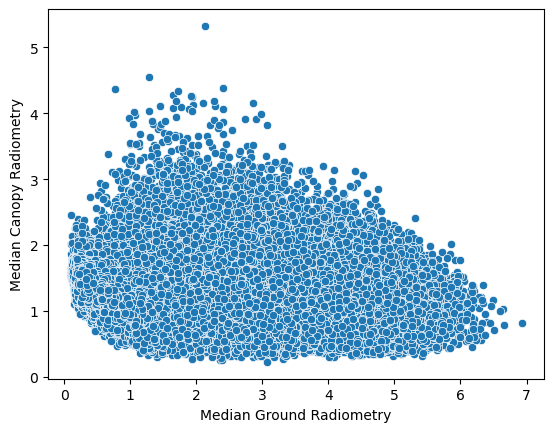

In [22]:
plt.figure()
sns.scatterplot(data = df_grouped[(df_grouped['data_quantity'] >= 25)],
                x='Eg_strong',
                y='Ev_strong',
                # hue='date',
               )
plt.xlabel('Median Ground Radiometry')
plt.ylabel('Median Canopy Radiometry')
# plt.xlim(0,20)
# plt.ylim(0,20)
# plt.plot([2.5,0],[0,2.5],'r--') #LOF10_bin20 570 points
# plt.plot([2.5,0],[0,2.5],'r--') #LOF10_bin30 596 points
# plt.legend(loc='best')
plt.show()

In [23]:
# df_grouped[df_grouped[['Eg_strong', 'Ev_strong']].isna().any(axis=1)]

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import contextily as cx
from pyproj import Transformer


def classify_snow_from_eg_ev(
    df,
    eg_col="Eg_strong",
    ev_col="Ev_strong",
    out_col="snow_class",
):
    """
    Classify points using two Eg/Ev boundary lines.

    No Snow:
        Ev < -1.1441321206951998 * Eg + 3.148002097754706

    Canopy Snow:
        Ev > -0.560374754550808 * Eg + 3.693690457423686

    Ground Snow:
        between the two lines
    """

    df = df.copy()

    eg = df[eg_col]
    ev = df[ev_col]

    no_snow_line = -1.1441321206951998 * eg + 3.148002097754706
    canopy_snow_line = -0.560374754550808 * eg + 3.693690457423686

    df[out_col] = np.select(
        [
            ev < no_snow_line,
            ev > canopy_snow_line,
        ],
        [
            "No Snow",
            "Canopy Snow",
        ],
        default="Ground Snow",
    )

    df.loc[eg.isna() | ev.isna(), out_col] = "Missing"

    return df


def prepare_monthly_map_df(
    df,
    date_col="date",
    lat_col="lat",
    lon_col="lon",
):
    """
    Parse dates, add year/month columns, and prepare Web Mercator coordinates
    if contextily/pyproj are available.
    """

    df = df.copy()

    # Your dates are DD/MM/YYYY
    df[date_col] = pd.to_datetime(df[date_col], dayfirst=True, errors="coerce")

    df = df.dropna(subset=[date_col, lat_col, lon_col])

    df["year"] = df[date_col].dt.year
    df["month"] = df[date_col].dt.month
    df["month_name"] = df[date_col].dt.strftime("%b")

    transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
    x, y = transformer.transform(df[lon_col].to_numpy(), df[lat_col].to_numpy())
    df["x_map"] = x
    df["y_map"] = y

    return df


def _padded_extent(x, y, pad_frac=0.08, min_pad=1000):
    xmin, xmax = np.nanmin(x), np.nanmax(x)
    ymin, ymax = np.nanmin(y), np.nanmax(y)

    xpad = max((xmax - xmin) * pad_frac, min_pad)
    ypad = max((ymax - ymin) * pad_frac, min_pad)

    return xmin - xpad, xmax + xpad, ymin - ypad, ymax + ypad


def _sort_track_for_plot(g):
    """
    Sort points along the dominant coordinate direction so file_index lines
    are drawn sensibly.
    """

    lat_range = g["lat"].max() - g["lat"].min()
    lon_range = g["lon"].max() - g["lon"].min()

    if lat_range >= lon_range:
        return g.sort_values("lat")
    else:
        return g.sort_values("lon")


def plot_monthly_class_maps_by_year(
    df,
    folder=None,
    years=None,
    class_col="snow_class",
    file_col="file_index",
    same_extent="year",
    # connect_tracks=True,
    point_size=14,
    alpha=0.9,
    basemap=True,
    zoom="auto",
    figsize=(15, 18),
    annotate_tracks=True,
):
    """
    Make one 4x3 monthly map figure per year.

    Parameters
    ----------
    df : DataFrame
        Must contain lat, lon, date, Eg_strong, Ev_strong, file_index.
    folder : str or None
        If given, only plot this folder.
    years : list or None
        If given, only plot these years.
    same_extent : {"year", "month", "all"}
        "year"  = all months in a year use same extent.
        "month" = each month zooms to its own data.
        "all"   = every subplot uses the full dataset extent.
    connect_tracks : bool
        If True, draws faint lines connecting points with the same file_index.
    """

    df = df.copy()

    if folder is not None:
        df = df[df["folder"] == folder].copy()

    if years is not None:
        df = df[df["year"].isin(years)].copy()

    if len(df) == 0:
        raise ValueError("No data left after filtering.")

    basemap_source = cx.providers.CartoDB.Positron

    class_colors = {
        "No Snow": "tab:gray",
        "Ground Snow": "tab:blue",
        "Canopy Snow": "tab:orange",
        # "Missing": "tab:red",
    }

    month_names = {
        1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
        5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
        9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec",
    }

    figures = {}

    if same_extent == "all":
        all_extent = _padded_extent(df["x_map"], df["y_map"])
    else:
        all_extent = None

    for year, year_df in df.groupby("year"):
        fig, axes = plt.subplots(4, 3, figsize=figsize, constrained_layout=True)
        axes = axes.ravel()

        if same_extent == "year":
            year_extent = _padded_extent(year_df["x_map"], year_df["y_map"])
        else:
            year_extent = None

        for month in range(1, 13):
            ax = axes[month - 1]
            month_df = year_df[year_df["month"] == month].copy()

            if len(month_df) == 0:
                ax.set_title(f"{month_names[month]} {year}\nNo data")
                ax.axis("off")
                continue

            if same_extent == "month":
                extent = _padded_extent(month_df["x_map"], month_df["y_map"])
            elif same_extent == "year":
                extent = year_extent
            elif same_extent == "all":
                extent = all_extent
            else:
                raise ValueError("same_extent must be one of: 'year', 'month', 'all'")

            xmin, xmax, ymin, ymax = extent
            ax.set_xlim(xmin, xmax)
            ax.set_ylim(ymin, ymax)

            if basemap:
                try:
                    cx.add_basemap(
                        ax,
                        source=basemap_source,
                        zoom=zoom,
                        attribution_size=5,
                        reset_extent=True,
                    )
                except Exception as e:
                    print(f"Basemap failed for {month_names[month]} {year}: {e}")

            # if connect_tracks and file_col in month_df.columns:
            #     for _, g in month_df.groupby(file_col):
            #         if len(g) < 2:
            #             continue
            #         g = _sort_track_for_plot(g)
            #         ax.plot(
            #             g["x_map"],
            #             g["y_map"],
            #             color="black",
            #             linewidth=0.5,
            #             alpha=0.25,
            #             zorder=2,
            #         )

            for snow_class, g in month_df.groupby(class_col):
                ax.scatter(
                    g["x_map"],
                    g["y_map"],
                    s=point_size,
                    alpha=alpha,
                    color=class_colors.get(snow_class, "black"),
                    label=snow_class,
                    edgecolor="none",
                    zorder=3,
                )

            if annotate_tracks and file_col in month_df.columns:
                _annotate_groundtracks(ax, month_df, extent, file_col=file_col, date_col="date")

            ax.set_title(f"{month_names[month]} {year}\nn = {len(month_df)}")
            ax.set_xticks([])
            ax.set_yticks([])

        legend_handles = [
            Line2D(
                [0], [0],
                marker="o",
                linestyle="",
                markersize=8,
                color=color,
                label=label,
            )
            for label, color in class_colors.items()
            if label in df[class_col].unique()
        ]

        fig.legend(
            handles=legend_handles,
            loc="lower center",
            ncol=len(legend_handles),
            frameon=False,
            bbox_to_anchor=(0.5, -0.01),
        )

        title = f"Snow classification maps: {year}"
        if folder is not None:
            title += f" — {folder}"

        fig.suptitle(title, fontsize=18)

        figures[year] = fig

    return figures

def _annotate_groundtracks(ax, month_df, extent, file_col="file_index", date_col="date", fontsize=7):
    xmin, xmax, ymin, ymax = extent
    offset = 0.035 * max(xmax - xmin, ymax - ymin)

    all_pts = month_df[[file_col, "x_map", "y_map"]].to_numpy()

    for fid, g in month_df.groupby(file_col):
        pts = g[["x_map", "y_map"]].to_numpy()
        if len(pts) == 0:
            continue

        other = all_pts[all_pts[:, 0] != fid][:, 1:].astype(float)

        if len(other) > 0:
            d2 = ((pts[:, None, :] - other[None, :, :]) ** 2).sum(axis=2)
            best_idx = np.argmax(np.min(d2, axis=1))   # most isolated point on this track
            anchor = pts[best_idx]
            nearest_other = other[np.argmin(d2[best_idx])]
            vec = anchor - nearest_other
        else:
            anchor = pts[len(pts) // 2]
            vec = np.array([1.0, 1.0])

        norm = np.hypot(vec[0], vec[1])
        if norm == 0:
            vec = np.array([1.0, 1.0])
            norm = np.hypot(vec[0], vec[1])
        vec = vec / norm

        text_xy = anchor + offset * vec
        label = pd.to_datetime(g[date_col].iloc[0]).strftime("%d/%m/%Y")

        ax.annotate(
            label,
            xy=anchor,
            xytext=text_xy,
            fontsize=fontsize,
            color="black",
            ha="left" if vec[0] >= 0 else "right",
            va="bottom" if vec[1] >= 0 else "top",
            arrowprops=dict(arrowstyle="-", color="black", lw=0.8),
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.8),
            zorder=4,
        )

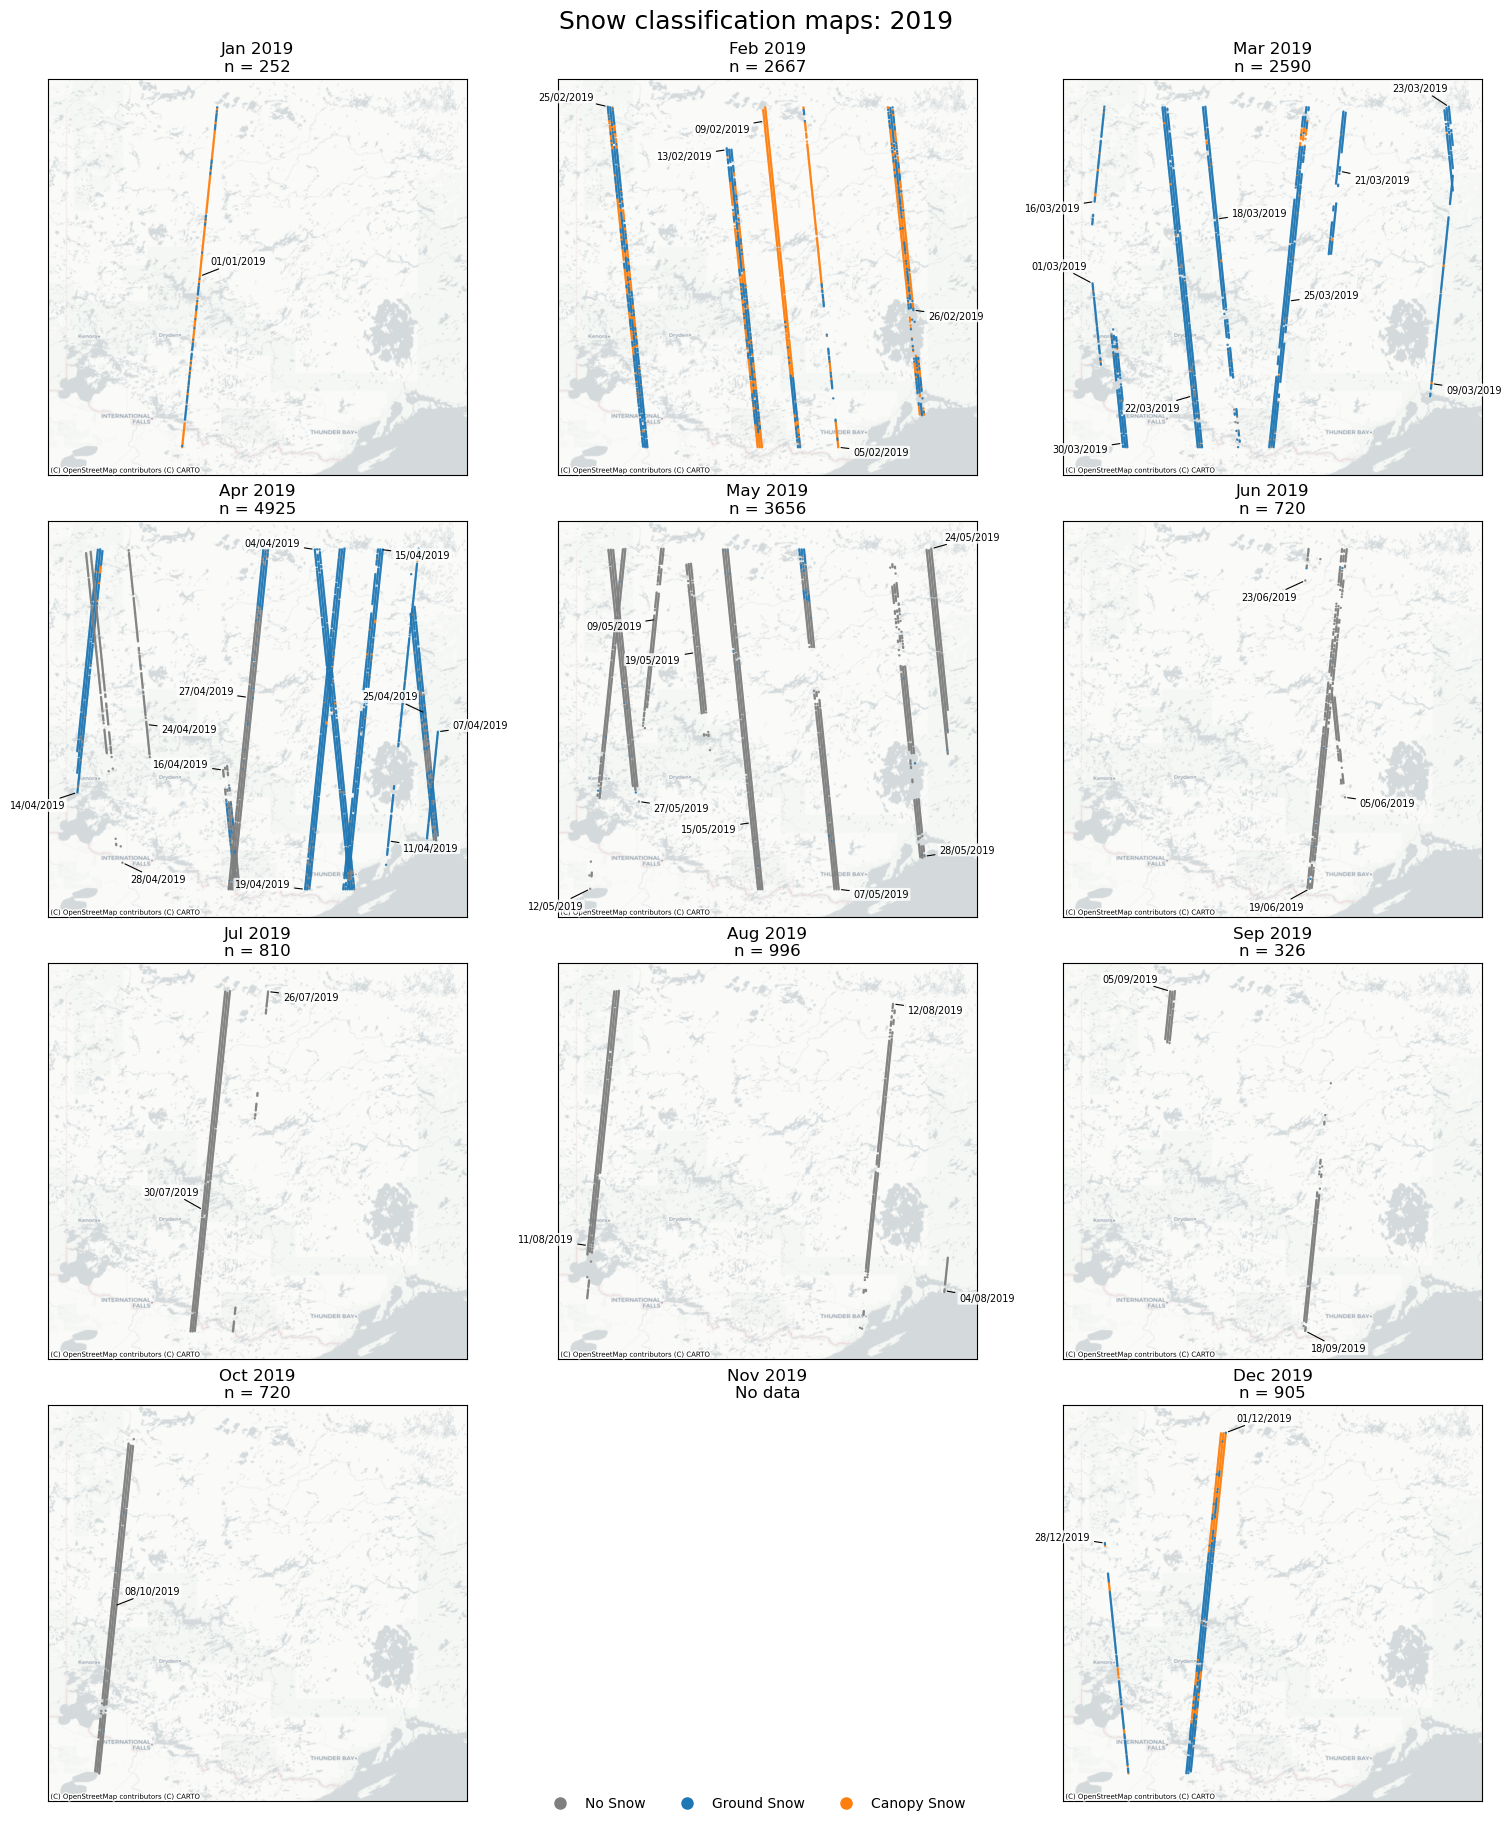

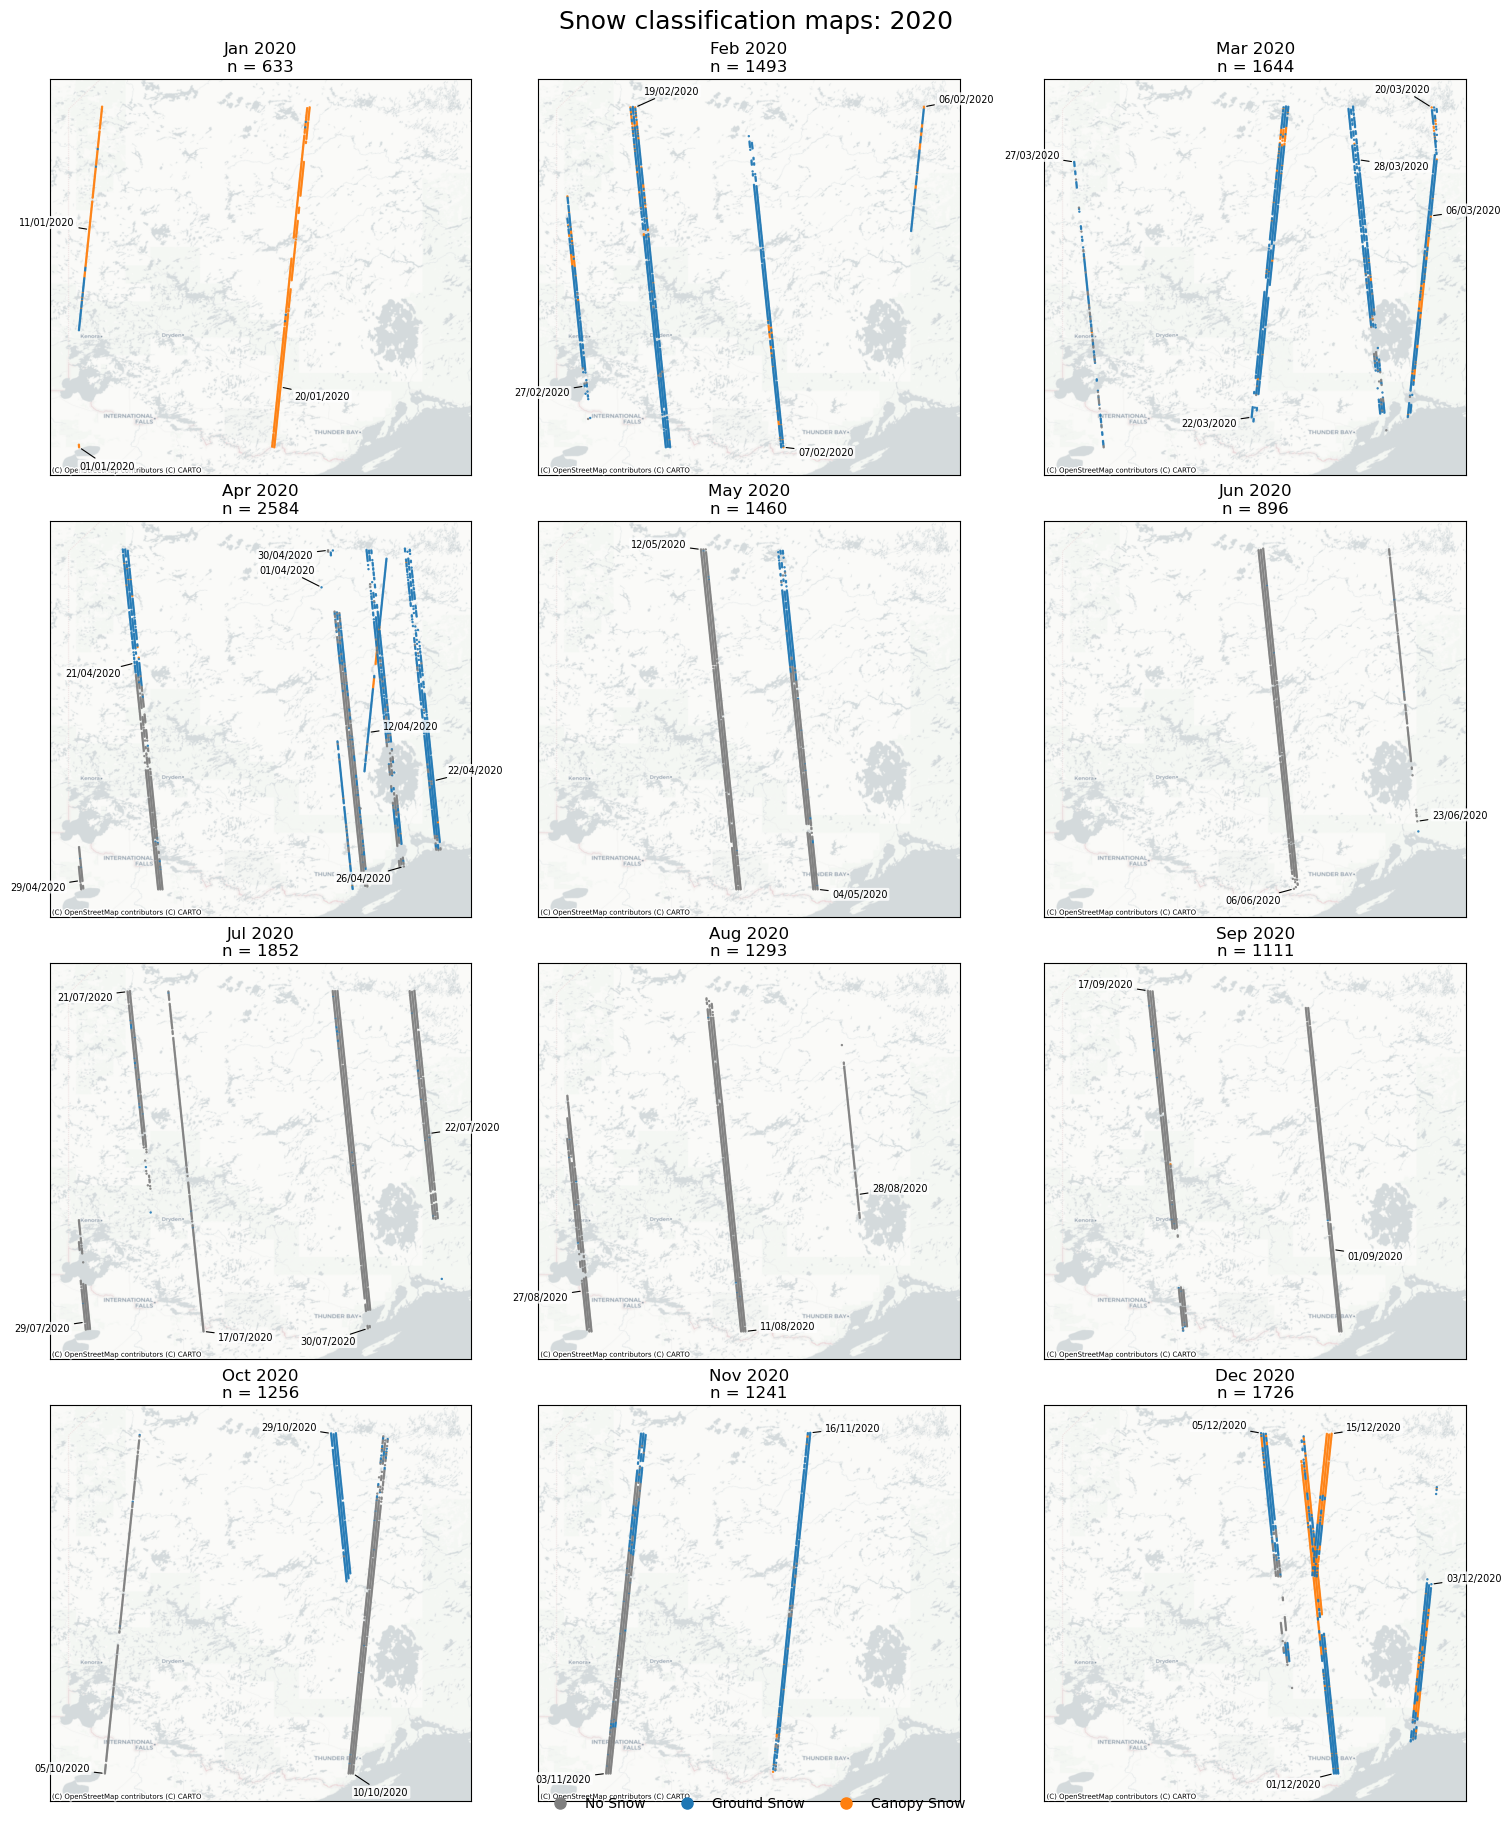

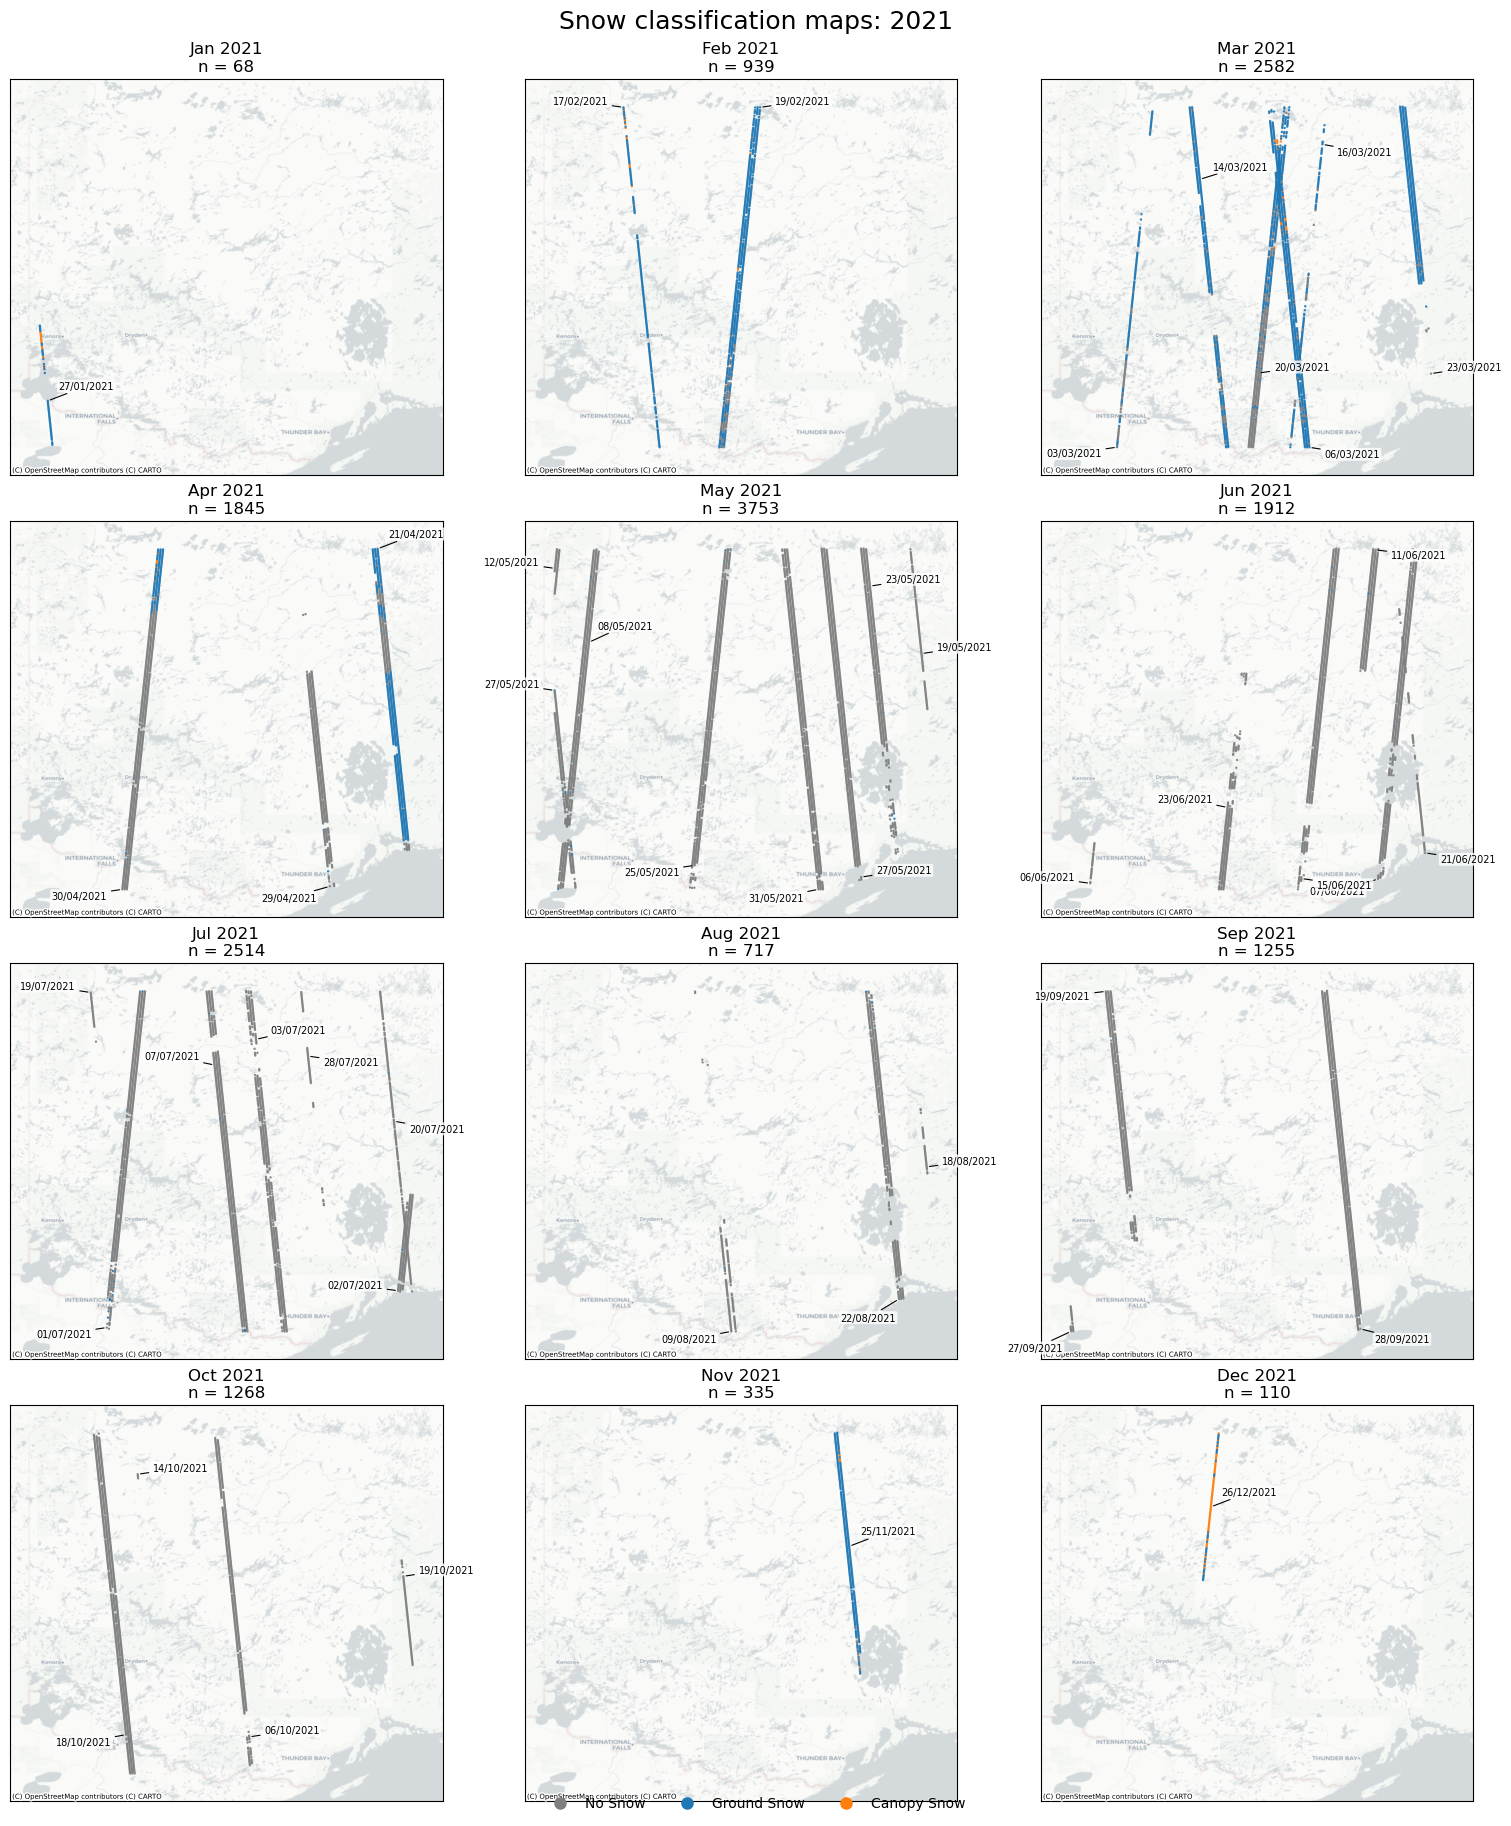

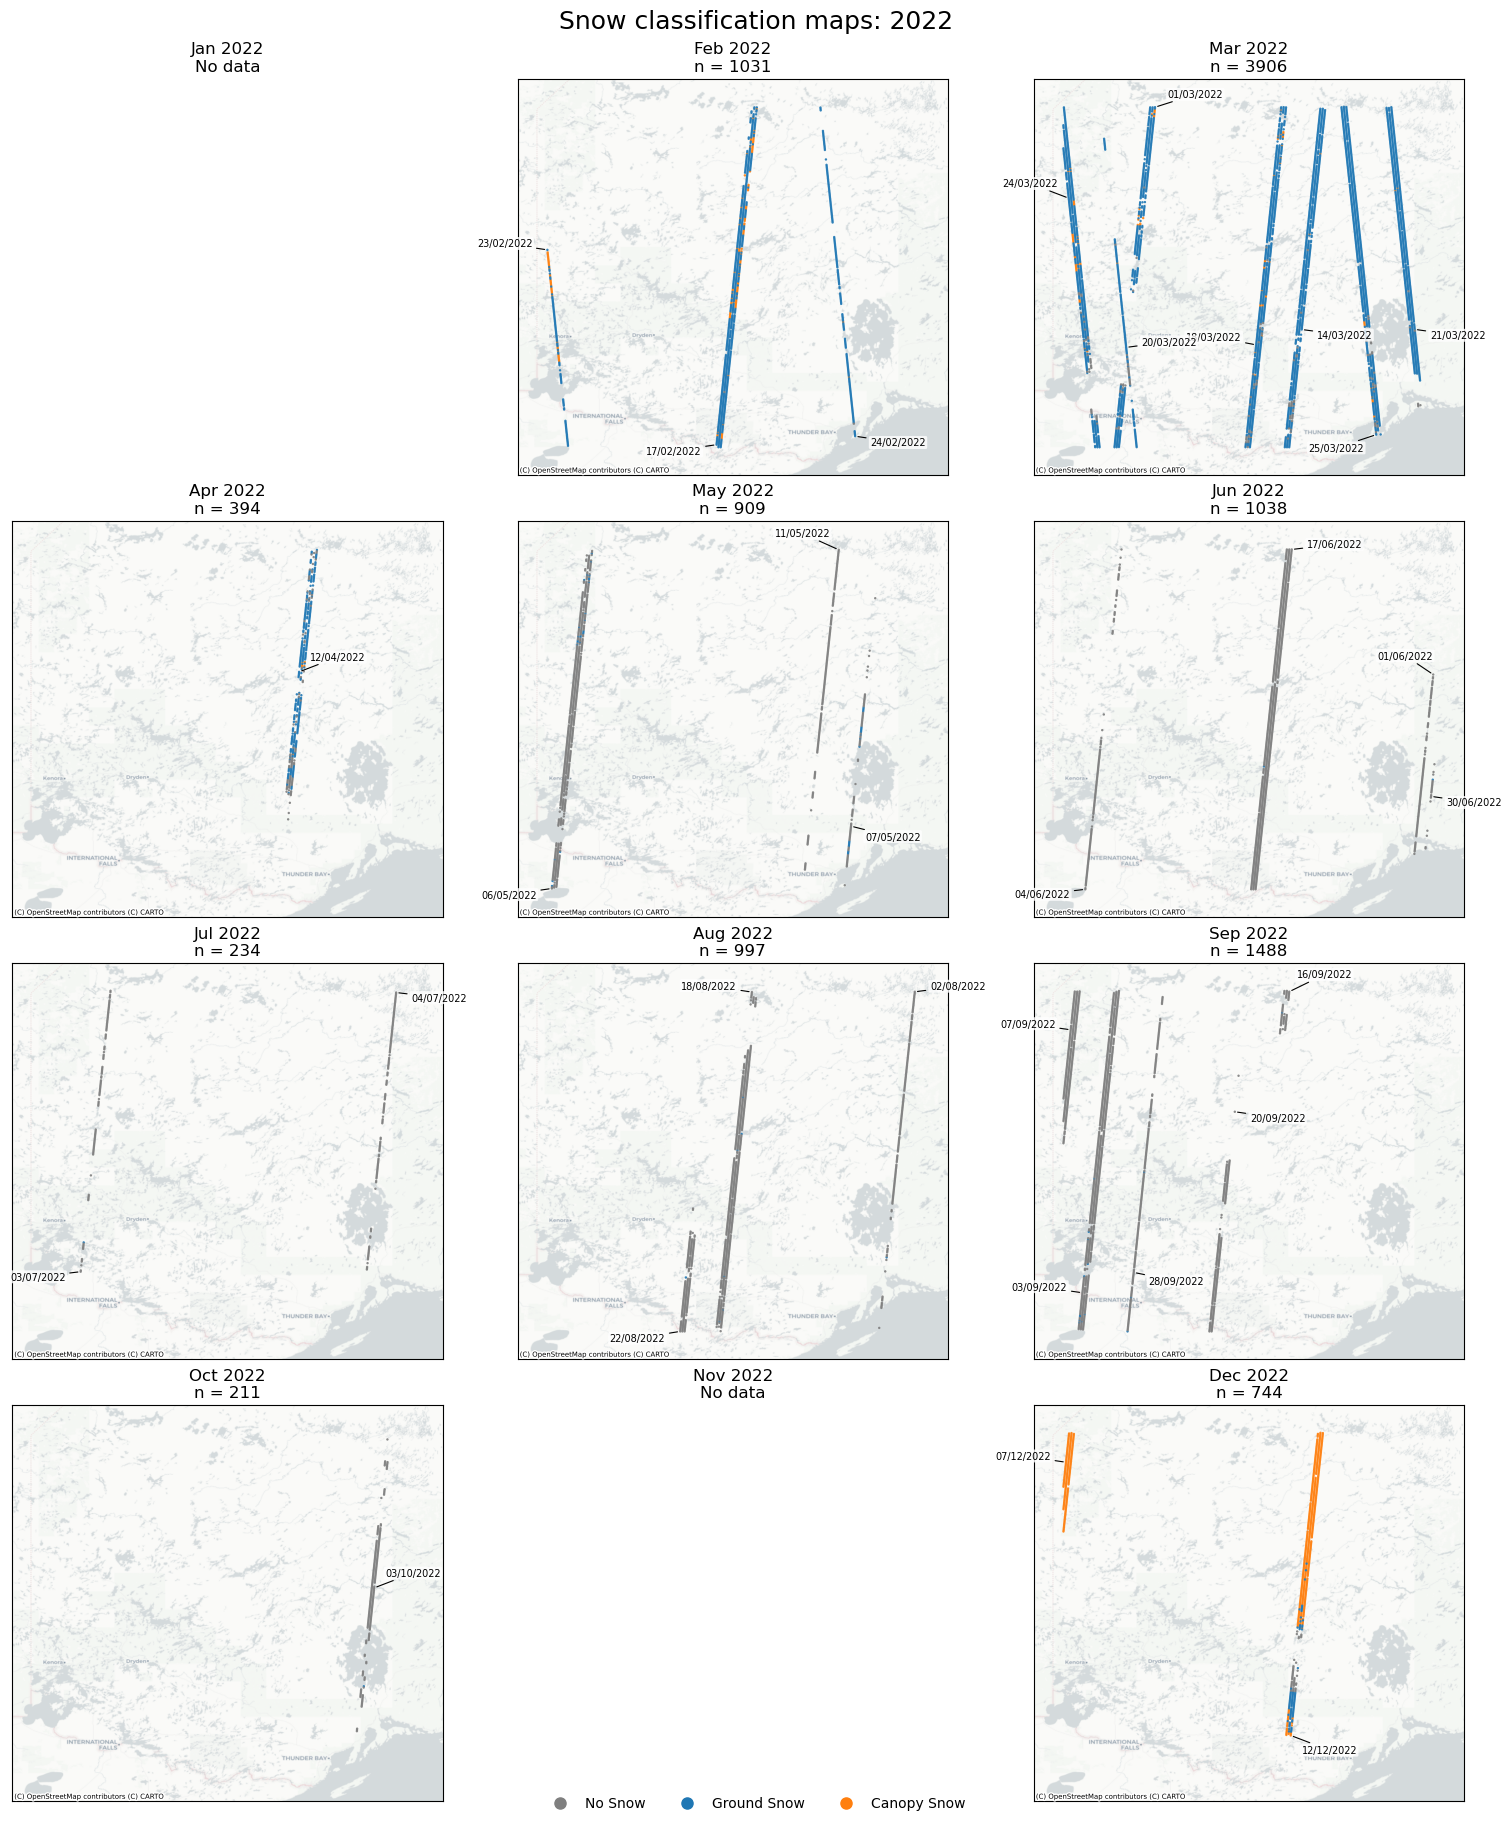

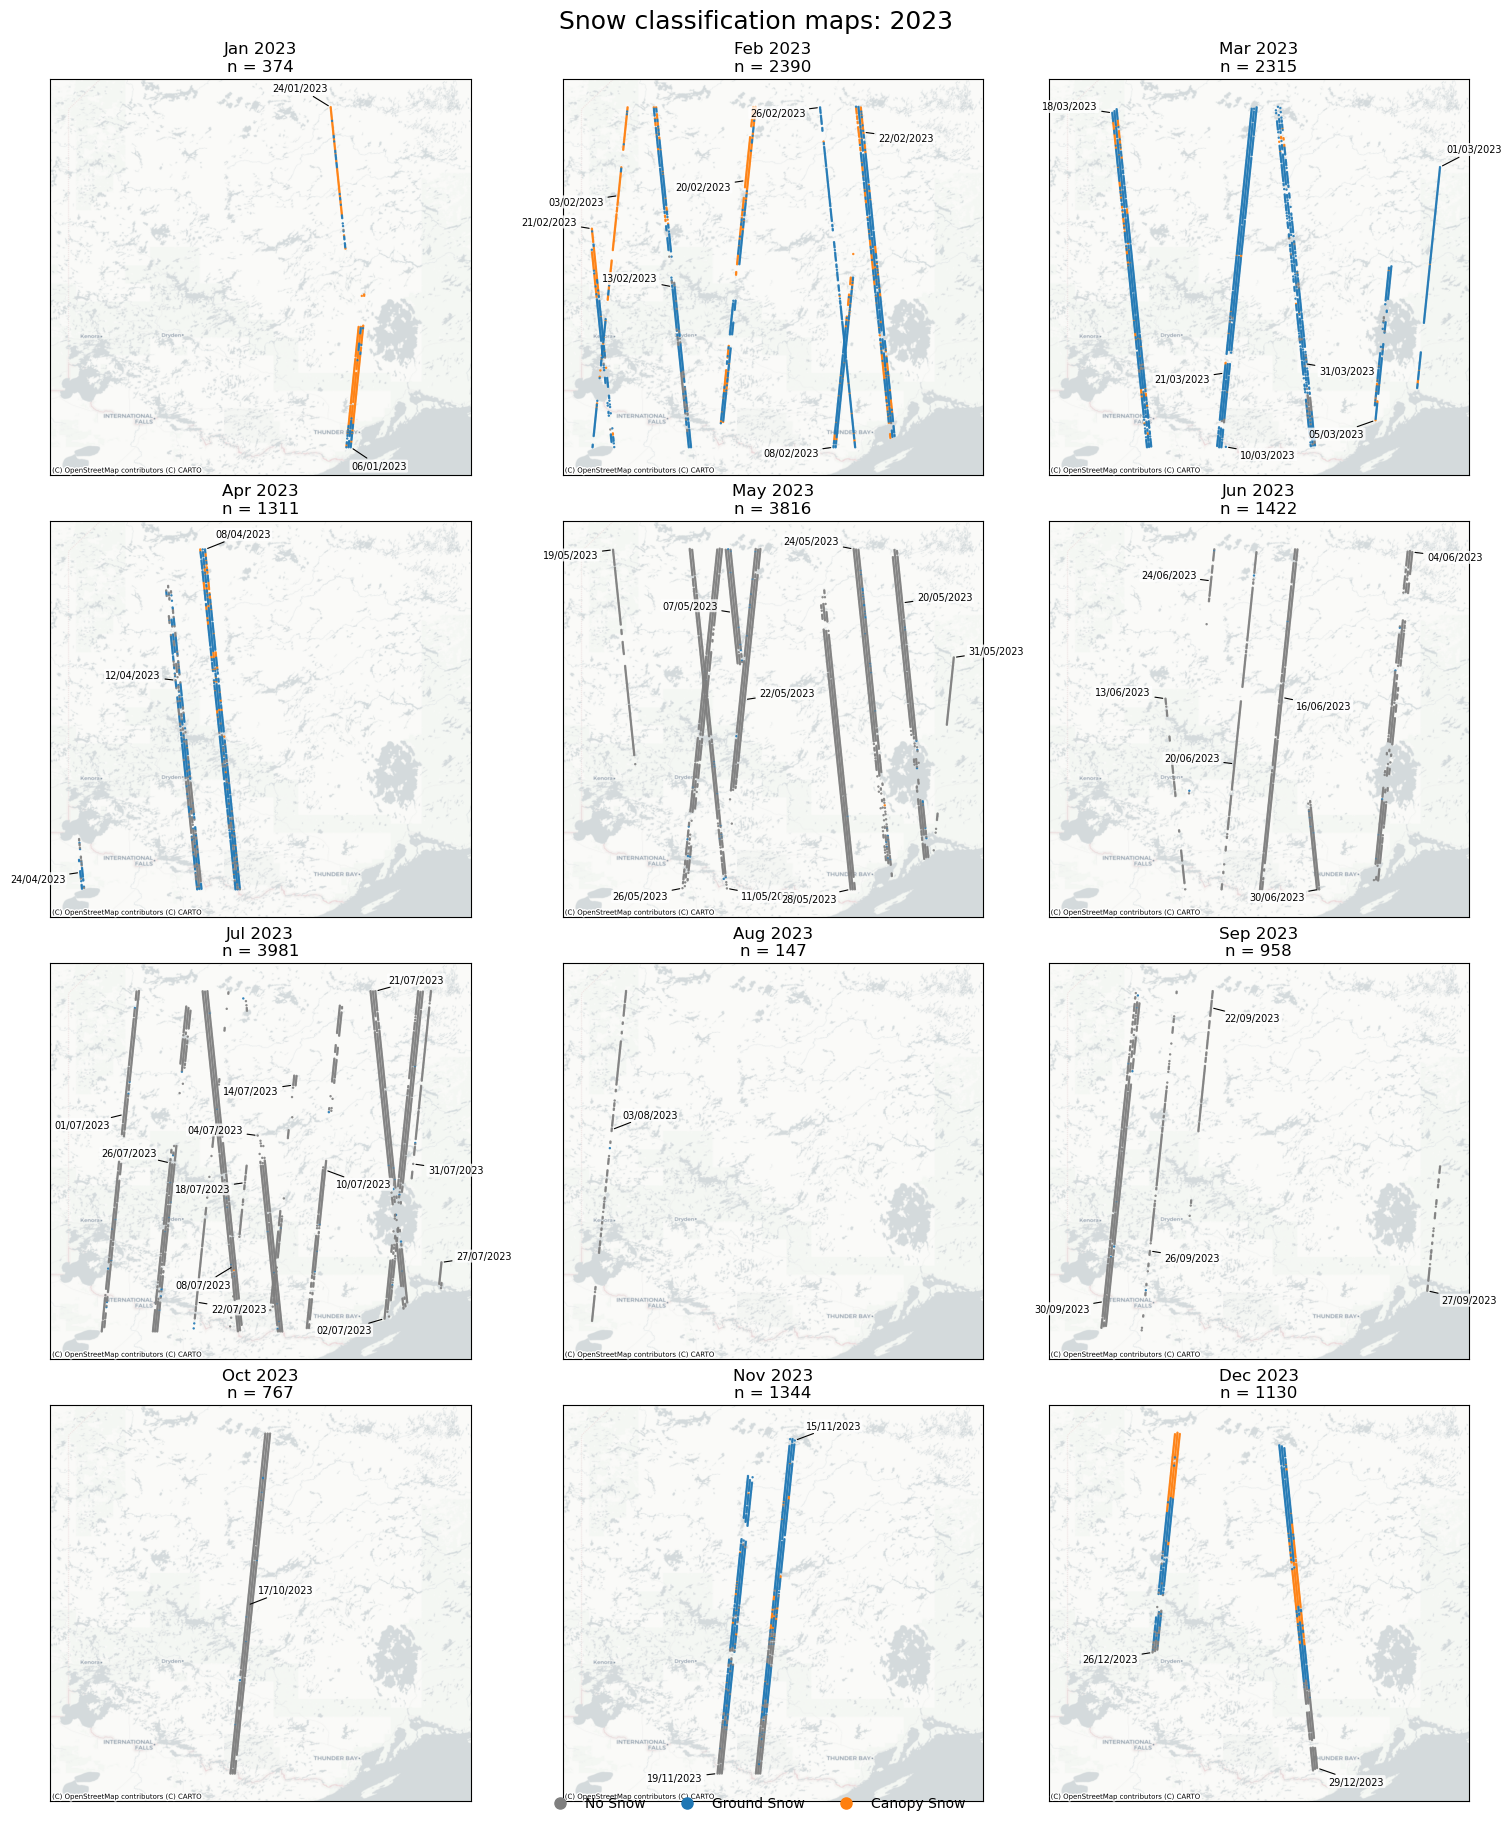

In [10]:
df_map = classify_snow_from_eg_ev(df_grouped)

df_map = prepare_monthly_map_df(df_map)

figures = plot_monthly_class_maps_by_year(
    df_map,
    folder=None,          # or set e.g. folder="sodankyla"
    years=[2019, 2020, 2021, 2022, 2023],           # or set e.g. years=[2018, 2019, 2020]
    same_extent="all",   # "year", "month", or "all"
    point_size=3,
    alpha=0.9,
    basemap=True,
    zoom="auto",
)